In [1]:
import sys

sys.path.append("..")
from src import *

Cupy Available= 1


In [2]:
max_frames = None
dataset = "synthetic"
variant = 15
segment_net = "cellpose"

In [3]:
meta = DATASETS[dataset]

x = Recording(meta.x, max_frames=max_frames).np
y_dcad = Recording(f"dataset/{dataset}/deepcad_{variant}/data.tiff", max_frames=max_frames).np
y_f2c = Recording(f"dataset/{dataset}/fft_{variant}/data.tiff", max_frames=max_frames).np
gt = Recording(meta.gt, max_frames=max_frames).np

In [4]:
mask_dcad = np.load(f"{segment_net}_results/{dataset}/deepcad_{variant}/cpsam_mask_cleaned.npy")
mask_f2c = np.load(f"{segment_net}_results/{dataset}/fft_{variant}/cpsam_mask_cleaned.npy")
mask_gt = np.load(f"{segment_net}_results/{dataset}/gt/cpsam_mask_cleaned.npy")

In [5]:
class ROI:
    def __init__(self, label, coords: tuple[np.array, np.array], mask):
        self.label = int(label)
        self.coords = np.vstack(coords).T
        self.ys, self.xs = coords
        self.centroid = (self.ys.mean(), self.xs.mean())
        self.area = self.ys.size
        self.mask = mask


# Funs
def mask2rois(mask: np.ndarray) -> list[ROI]:
    rois = []
    H, W = mask.shape
    for label in np.unique(mask):
        ys, xs = np.nonzero(mask == label)
        if ys.size == 0 or label == 0:
            continue
        roi_mask = np.zeros((H, W), dtype=bool)
        roi_mask[ys, xs] = True
        rois.append(ROI(label, (ys, xs), roi_mask))
    return rois


def get_traces(vid: np.ndarray, rois: list[ROI]) -> np.ndarray:
    return np.array([vid[:, r.ys, r.xs].mean(axis=1) for r in rois])

In [ ]:
def pairwise_pearson(traces: np.ndarray) -> np.ndarray:
    return np.corrcoef(traces)

def pairwise_distances(rois: list[ROI], pixel_size_um: float=1.0) -> np.ndarray:
    centroids = np.array([r.centroid for r in rois])
    dy = centroids[:, None, 0] - centroids[None, :, 0]
    dx = centroids[:, None, 1] - centroids[None, :, 1]
    return np.sqrt(dx**2 + dy**2) * pixel_size_um

In [ ]:
def get_pearsons(vid, mask, exclusive: bool, bin_size=10, rois=None):
    assert len(mask.shape) == 2
    if not rois:
        rois = mask2rois(mask)
    traces = get_traces(vid, rois)

    distances = range(0, 600, bin_size)
    roi_distances = pairwise_distances(rois)
    roi_pearsons = pairwise_pearson(traces)

    distances = np.asarray(distances)
    n = len(rois)
    i_idx, j_idx = np.where(np.ones((n, n), dtype=bool))
    mask_neq = i_idx != j_idx

    dij = roi_distances[i_idx, j_idx]
    pij = roi_pearsons[i_idx, j_idx]

    pearsons = {}
    for d in tqdm(distances):
        if exclusive:
            m = mask_neq & (dij <= d) & (dij > d - bin_size)
        else:
            m = mask_neq & (dij <= d)

        vals = pij[m]
        pearsons[d] = float(vals.mean()) if vals.size else 0.0

    return pearsons

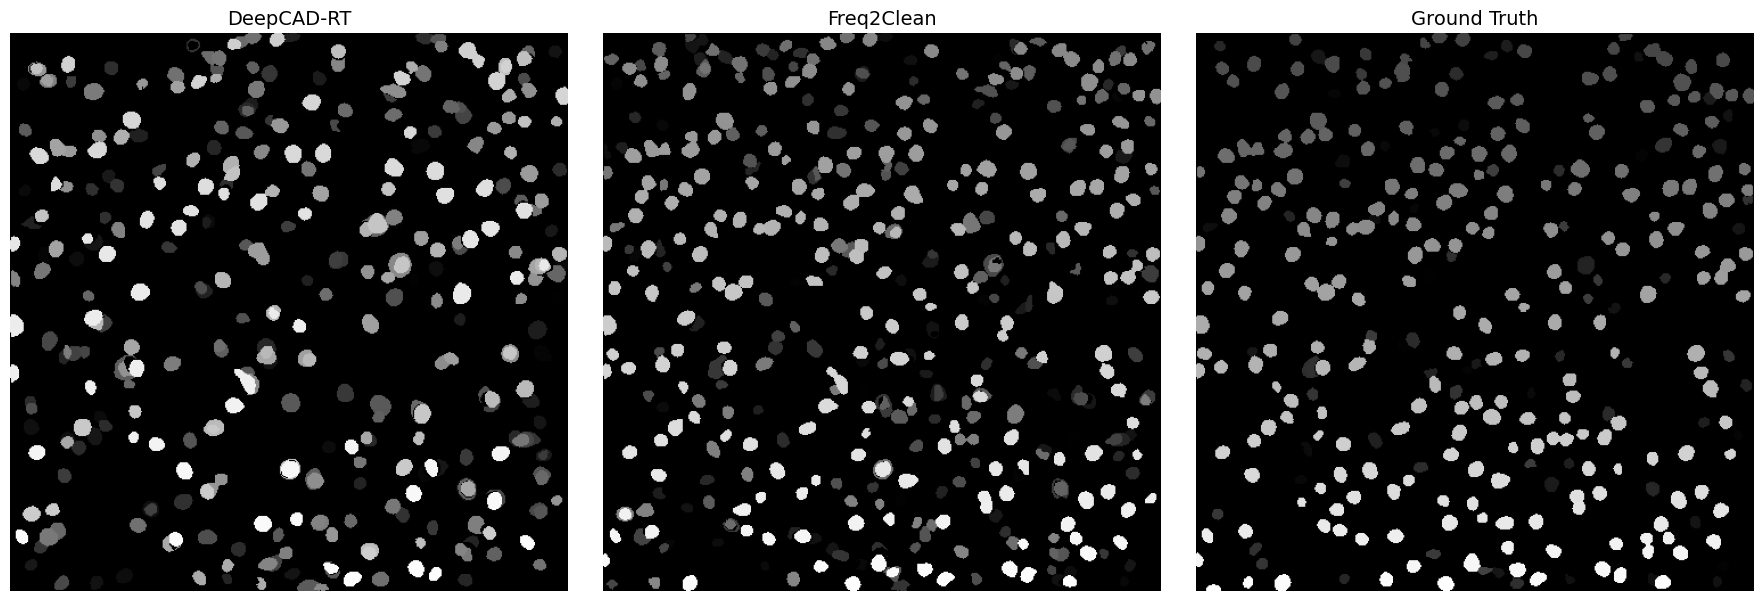

In [8]:
imshow({"DeepCAD-RT":mask_dcad,"Freq2Clean":mask_f2c,"Ground Truth":mask_gt}, size=6)

In [9]:
gt_rois = mask2rois(mask_gt)
pearsons_dcad = get_pearsons(y_dcad, mask_dcad, bin_size=3, exclusive=True)
pearsons_f2c = get_pearsons(y_f2c, mask_f2c, bin_size=3, exclusive=True)
pearsons_gt = get_pearsons(gt, mask_gt, bin_size=3, exclusive=True)

100%|██████████| 200/200 [00:00<00:00, 18176.83it/s]


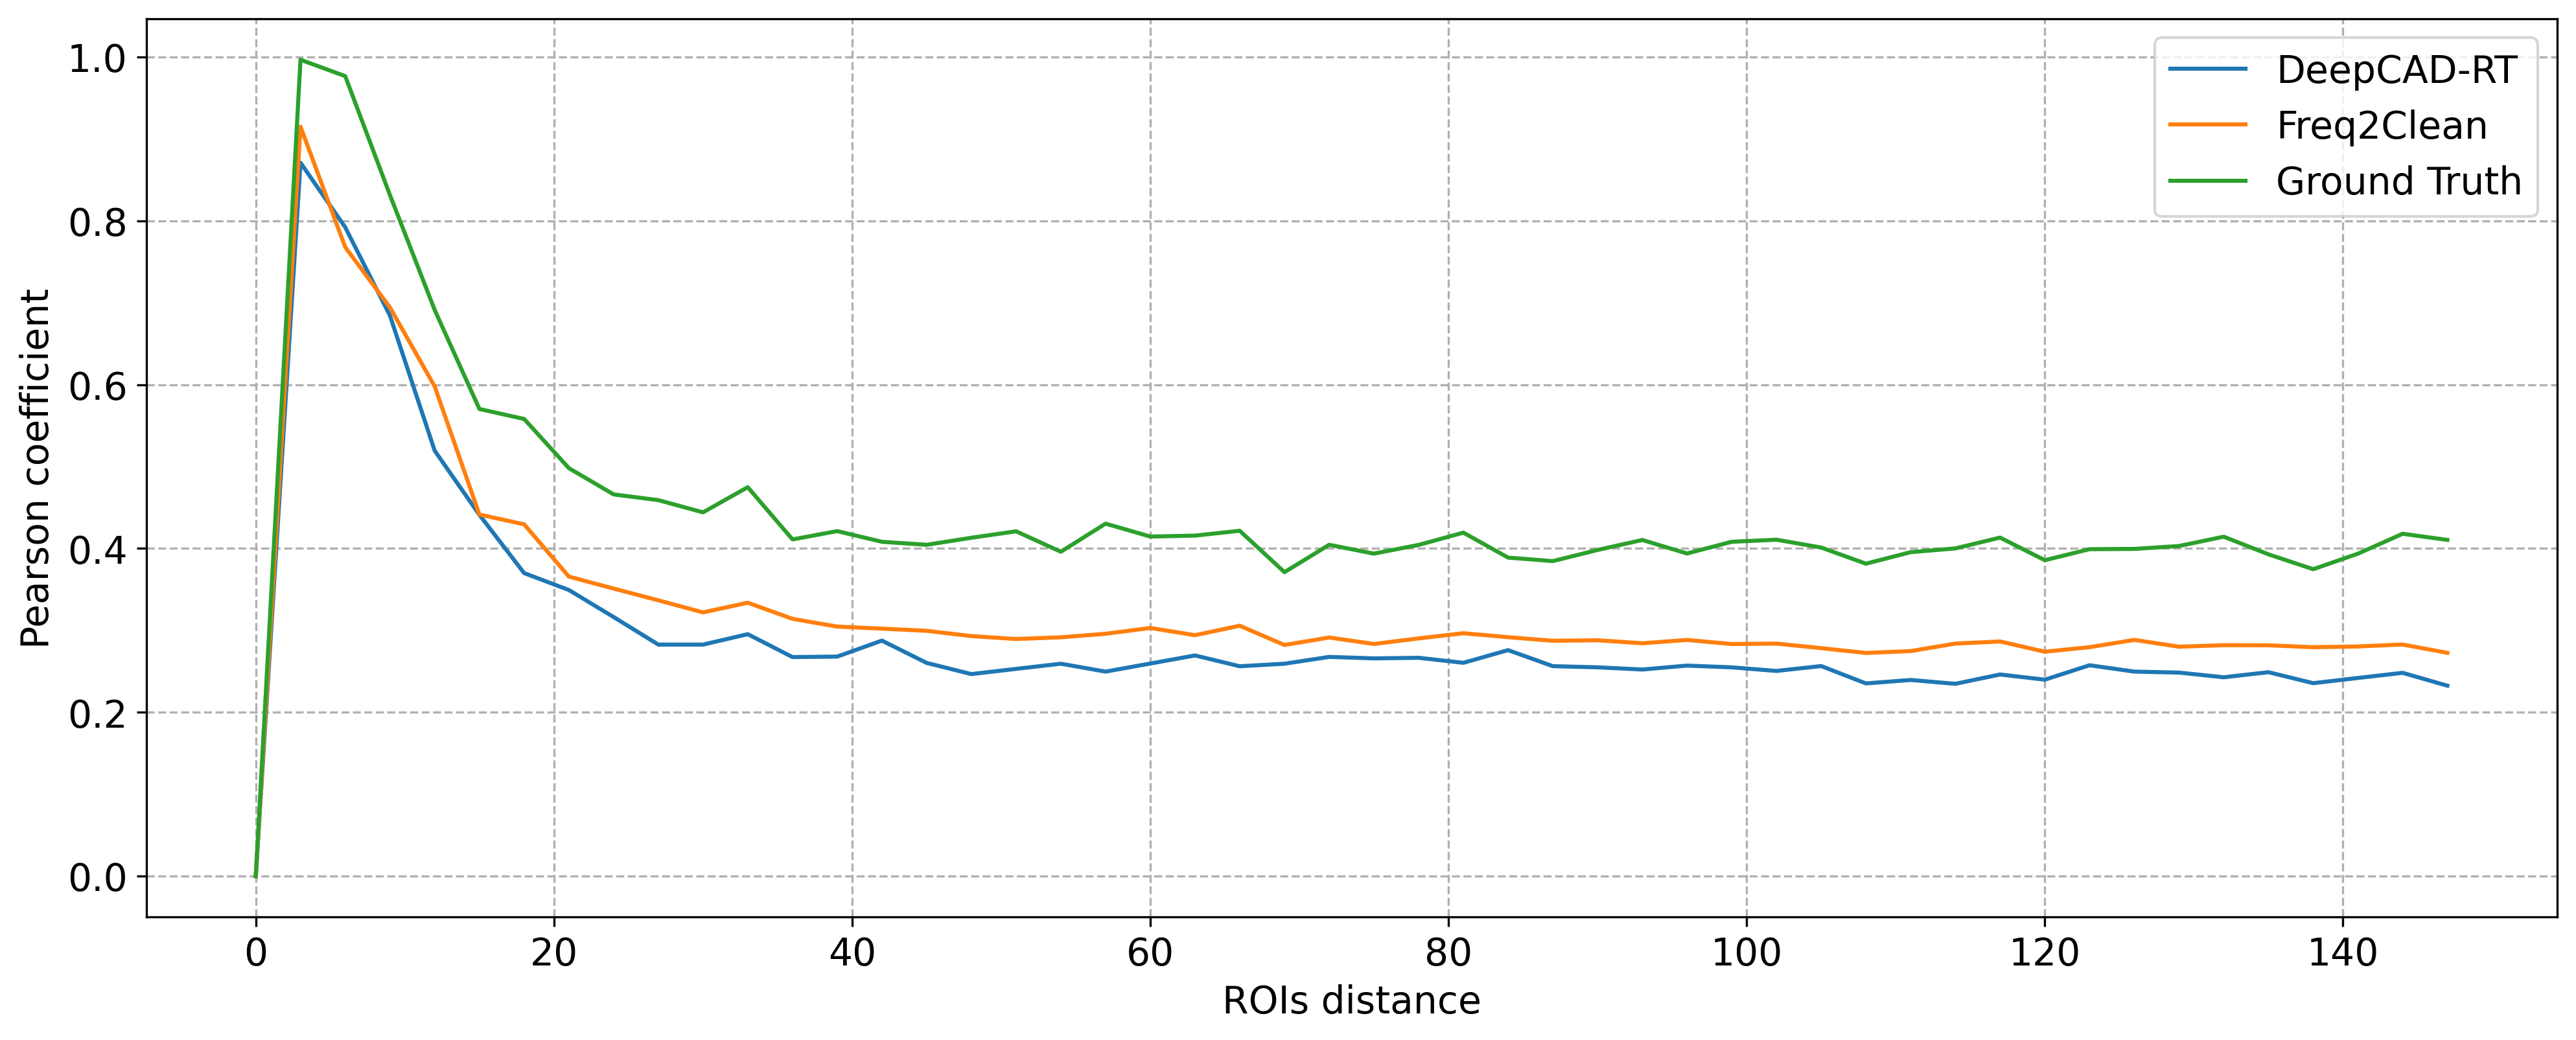

In [10]:
fig = plt.figure(figsize=(16, 6), dpi=300)
ax = pd.Series(pearsons_dcad)[:50].plot(kind="line", label="DeepCAD-RT", ax=plt.gca())
pd.Series(pearsons_f2c)[:50].plot(kind="line", ax=plt.gca(), label="Freq2Clean")
pd.Series(pearsons_gt)[:50].plot(kind="line", ax=plt.gca(), label="Ground Truth")

plt.xlabel("ROIs distance")
plt.ylabel("Pearson coefficient")
plt.legend()
plt.show()

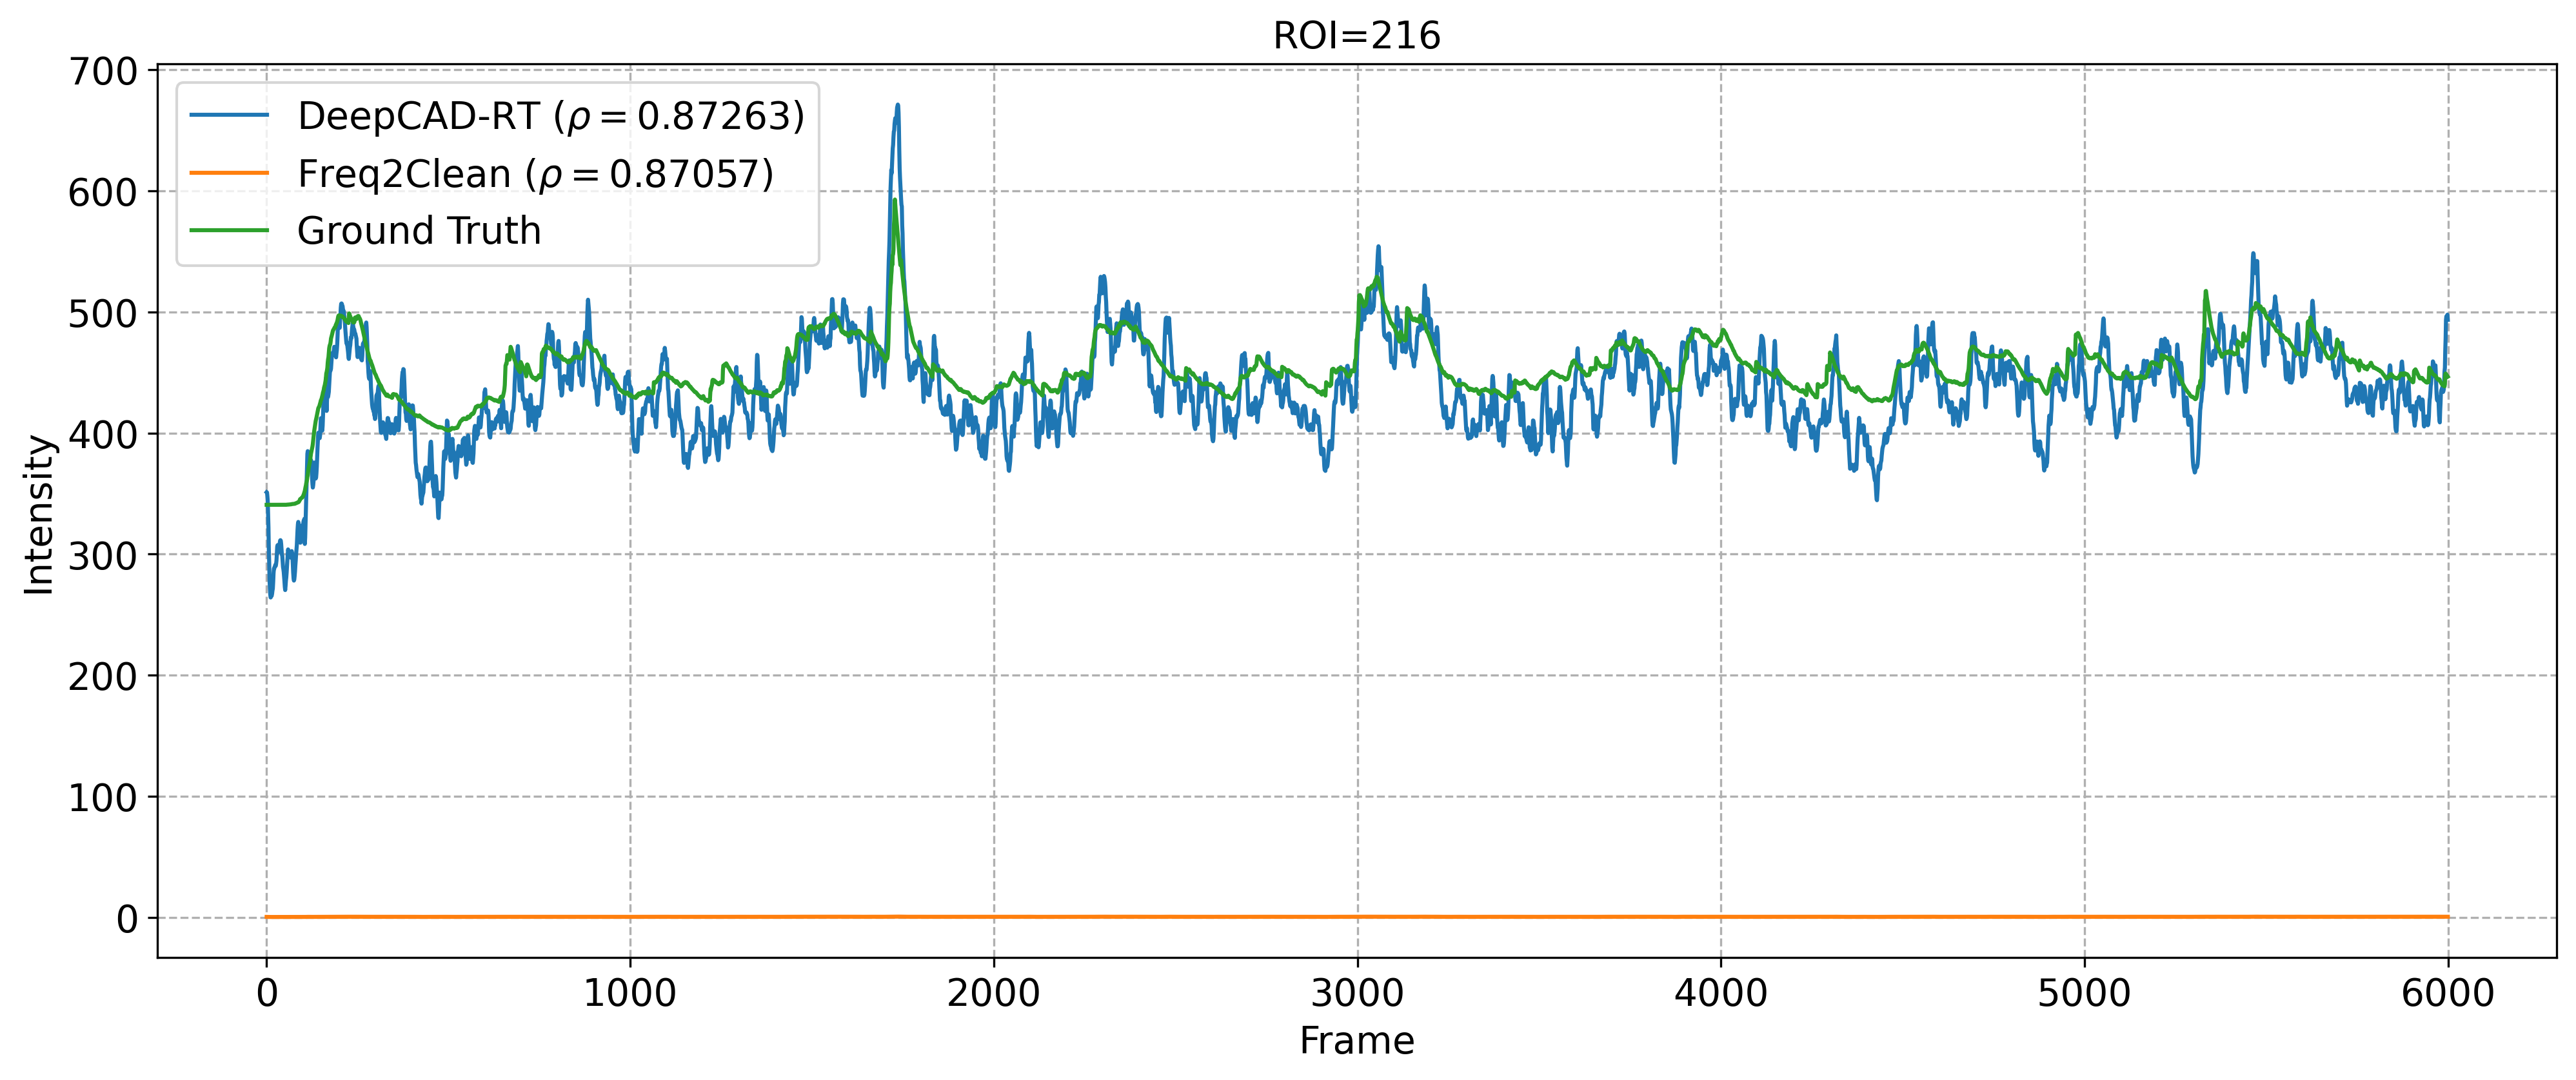

In [ ]:
roi = random.randrange(len(gt_rois))
trace_dcad = pd.Series(get_traces(y_dcad, gt_rois)[roi])
trace_f2c = pd.Series(get_traces(y_f2c, gt_rois)[roi])
trace_gt = pd.Series(get_traces(gt, gt_rois)[roi])

fig = plt.figure(figsize=(16, 6), dpi=300)
ax = trace_dcad.plot(
    kind="line",
    label=f"DeepCAD-RT ($\\rho={trace_dcad.corr(trace_gt,method="pearson"):.5f}$)",
    ax=plt.gca(),
)
trace_f2c.plot(
    kind="line",
    ax=plt.gca(),
    label=f"Freq2Clean ($\\rho={trace_f2c.corr(trace_gt,method="pearson"):.5f}$)",
)
trace_gt.plot(kind="line", ax=plt.gca(), label="Ground Truth")

plt.xlabel("Frame")
plt.ylabel("Intensity")
plt.title(f"ROI={roi}")
plt.legend()
plt.show()

In [66]:
traces_dcad = get_traces(y_dcad, gt_rois)
traces_f2c = get_traces(y_f2c, gt_rois)
traces_gt = get_traces(gt, gt_rois)

deepcad_pearsons = []
freq2clean_pearsons = []
for i in trange(len(gt_rois)):
    trace_dcad = pd.Series(traces_dcad[i])
    trace_f2c = pd.Series(traces_f2c[i])
    trace_gt = pd.Series(traces_gt[i])
    deepcad_pearsons.append(trace_dcad.corr(trace_gt, method="pearson"))
    freq2clean_pearsons.append(trace_f2c.corr(trace_gt, method="pearson"))

100%|██████████| 314/314 [00:00<00:00, 7008.51it/s]


In [67]:
sum(deepcad_pearsons)/len(gt_rois),sum(freq2clean_pearsons)/len(gt_rois)

(np.float64(0.9084195286611447), np.float64(0.9071580987867494))